# Part 12: Kernel Density Estimation {-}

The discussion of maximum likelihood concerns the problem of
fitting **parametric** models to data. In other words, a
particular parametric form is assumed for the probability
model (e.g., normal, exponential, etc.) and the parameters
of those models are estimated from data using the MLE.

One could view fitting parametric models as **parametric
density estimation** in the case that the data is best
modelled using a continuous distribution.

**Nonparametric density estimation** refers to techniques that
estimate the **distribution** for a variable, without assuming
any parametric form. We can view this operation as a "smoothing"
of the observed data, done in a manner that allows the data to
define the shape of the density.

\newpage

**Histograms** are a simple example of a nonparametric density
estimator. While these are useful, they suffer from limitations, namely the
arbitrariness of the binning, and discontinuous ("jagged") nature of the estimate of
a distribution
that is typically assumed to be smooth. Smooth estimators also have statistical
efficiency
advantages over histograms.

The standard (smooth) nonparametric approach to density estimation is the 
**kernel density estimator**. This estimate is constructed
by summing a smooth **kernel function** centered at each
of the observed data points.

Formally, we write:
\begin{equation*}
\widehat f_{\!h}(x) = \frac{1}{nh} \sum_{i=1}^n K\!\left(\frac{x-x_i}{h}\right)
\end{equation*}
where $K(\cdot)$ is the **kernel function** and $h$ is
the **smoothing parameter** or **bandwidth**.
The sample is $x_1, x_2, \ldots, x_n$.

The kernel function is itself a density, almost always taken to be a
smooth density peaked at zero, and symetric around zero.

The package `KDEpy` incorporates nine different choices for
the kernel functions, as shown below.

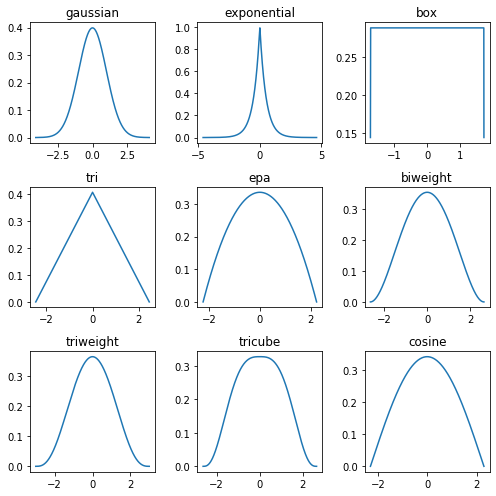

In [1]:
from KDEpy import FFTKDE
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(7, 7))
pos = 1

for name, func in FFTKDE._available_kernels.items():

    x, y = FFTKDE(kernel=name).fit([0]).evaluate()
    ax = fig.add_subplot(3, 3, pos)
    pos = pos + 1
    ax.set_title(name)
    ax.plot(x, y, label=name)

plt.tight_layout()

\newpage

The choice of the kernel is not too important: 
Any smooth kernel should do an adequate job of creating a useful
density estimate.
The bandwidth $h$ is influential, however.

Larger values of $h$ result in a density estimate that is smoother. Smaller values of $h$ produce an estimate that is "rough" and "wiggly."

As a very simple example to illustrate the concept, imagine my data set consisted of
three observations: 1.5, 4, and 5. The figure below illustrates the construction of the kernel
density estimator in the case where $h=1$.

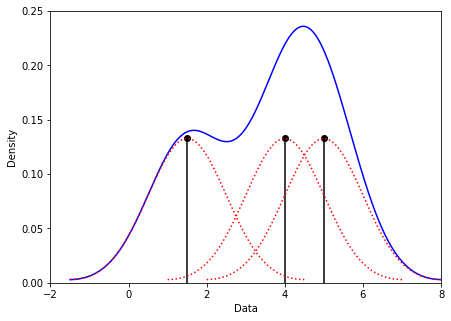

In [12]:
import statsmodels.api as sm

h = 1

x = [1.5, 4, 5]
n = len(x)
ht = 1 / np.sqrt(2 * np.pi) / n / h
y = [ht, ht, ht]

fig, axs = plt.subplots(figsize=(7, 5))
markerline, stemlines, baseline = axs.stem(x, y, basefmt=" ", use_line_collection=True)
plt.setp(stemlines, "color", "black")
plt.setp(markerline, "color", "black")
plt.xlim(-2, 8)
plt.ylim(0, 0.25)

kde = sm.nonparametric.KDEUnivariate(x)
kde.fit(kernel='gau', bw=h)
axs.plot(kde.support, kde.density, color="blue")

kde = sm.nonparametric.KDEUnivariate([1.5])
kde.fit(kernel='gau', bw=h)
axs.plot(kde.support, kde.density / n, color="red", linestyle="dotted")
kde = sm.nonparametric.KDEUnivariate([4.0])
kde.fit(kernel='gau', bw=h)
axs.plot(kde.support, kde.density / n, color="red", linestyle="dotted")
kde = sm.nonparametric.KDEUnivariate([5.0])
kde.fit(kernel='gau', bw=h)
axs.plot(kde.support, kde.density / n, color="red", linestyle="dotted")

axs.set_xlabel("Data")
axs.set_ylabel("Density")
plt.show()

\newpage

The cases where $h=2$, $h=0.5$, and $h=0.1$, respectively:

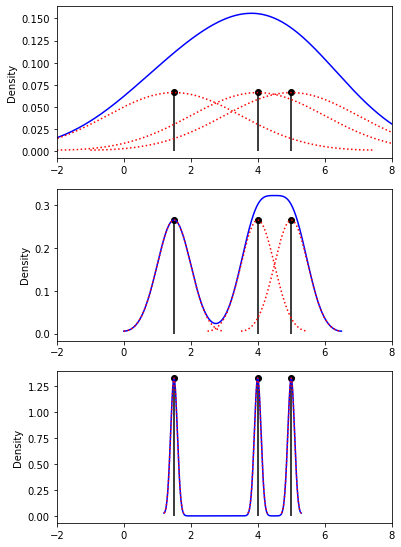

In [3]:
fig = plt.figure(figsize=(6, 9.5))

h = 2

pos = 1

for h in [2,0.5,0.1]:
    x = [1.5, 4, 5]
    n = len(x)
    ht = 1 / np.sqrt(2 * np.pi) / n / h
    y = [ht, ht, ht]
    
    axs = fig.add_subplot(3,1, pos)
    pos = pos + 1
    markerline, stemlines, baseline = axs.stem(x, y, basefmt=" ", use_line_collection=True)
    plt.setp(stemlines, "color", "black")
    plt.setp(markerline, "color", "black")
    plt.xlim(-2, 8)
    
    kde = sm.nonparametric.KDEUnivariate(x)
    kde.fit(kernel='gau', bw=h)
    axs.plot(kde.support, kde.density, color="blue")
    
    kde = sm.nonparametric.KDEUnivariate([1.5])
    kde.fit(kernel='gau', bw=h)
    axs.plot(kde.support, kde.density / n, color="red", linestyle="dotted")
    kde = sm.nonparametric.KDEUnivariate([4.0])
    kde.fit(kernel='gau', bw=h)
    axs.plot(kde.support, kde.density / n, color="red", linestyle="dotted")
    kde = sm.nonparametric.KDEUnivariate([5.0])
    kde.fit(kernel='gau', bw=h)
    axs.plot(kde.support, kde.density / n, color="red", linestyle="dotted")
    #axs.set_xlabel("Data")
    axs.set_ylabel("Density")
    
    
plt.show()

\newpage

**Exercise:** Discuss the effect of varying $h$. How does it relate to the bias/variance tradeoff?

\answerlines{12}

**Exercise:** What is the relationship between using a Gaussian kernel and
making an assumption that a sample is drawn from a Gaussian (normal) distribution?

\answerlines{5}

\newpage

Rigorous ways of choosing $h$ do exist. See Jones, Marron, and Sheather (1996) for an
overview.

Briefly, the theory is built on the assumption that the
available sample $x_1, x_2, \ldots, x_n$ are drawn i.i.d. from some population with
density $f(\cdot)$. The criterion that one seeks to minimize is the \textcolor{red}{mean
integrated squared error}:
\begin{equation*}
   {\rm MISE} = E\left[\int \!\left(\widehat f_{\!h}(x) - f(x)\right)^2 \!dx \right].
\end{equation*}

As is often the case, consideration is made of the **asymptotic**
behavior of the criterion as $n$ increases. One can show that the the
**asymptotic mean integrated squared error** is
\begin{equation*}
   {\rm AMISE} = \frac{R(K)}{nh} + h^4 R(f'')\left(\frac{1}{2}\!\int \!x^2 K(x) \:dx\right)^2
\end{equation*}
where
\begin{equation*}
R(\phi) = \int \phi^2(x) \:dx
\end{equation*}

The optimal choice for $h$ can then be shown to be
\begin{equation*}
h = \left[
\frac{R(K)}{nR(f'')\left(x^2K(x)\right)^2}
\right]^{1/5}
\end{equation*}

The **Sheather-Jones (S-J)** approach to finding
the bandwidth is to find the $h$ which solves
\begin{equation*}
h = \left[
\frac{R(K)}{nR(\widehat f_{g(h)}'')\left(x^2K(x)\right)^2}
\right]^{1/5}
\end{equation*}
where $g(h)$ is some function of $h$ which accounts for the
fact that the optimal choice of bandwidth for estimating $f''$
is not the same as the optimal choice for estimating $f$.

\newpage

The choice of $h$ can also be dictated by less theoretical considerations.

In particular, if the motivation is to achieve a summary of a distribution
via **smoothing** the distribution to a particular **scale**.

One could, for example, smooth a distribution using multiple bandwidth
choices, and then using the resulting smooth estimates as input into a
model. Formal procedures could then be used to determine how useful each
"scale" is to the problem at hand, i.e., a prediction challenge.

\newpage

## Kernel Density Estimation in Python {-}

We will discuss the use of `KDEpy` for the purpose of kernel density estimation. More information can be found at
https://kdepy.readthedocs.io/en/latest/index.html.

This package includes a function `FFTKDE()` which implements a fast fourier transform-based algorithm for calculating the kernel density estimate, providing significant speedup. (See
https://kdepy.readthedocs.io/en/latest/introduction.html#Speed
for a discussion.)

The argument `kernel` specifies the kernel function; the
default is `"gaussian"`.

The bandwidth is provided using the argument `bw`. The user can specify either a number, or specify a method for determining the bandwidth: `bw="ISJ"` calculates an "improved" version of the S-J bandwidth, while `scott` and `silverman` are two **normal-reference** bandwidth selection approaches, meaning that they are optimized to work well when the underlying distribution is normal.

\newpage

**Exercise:**
Try the following code. Consider what happens as the sample size and the bandwidth selection method are varied.

\answerlines{10}

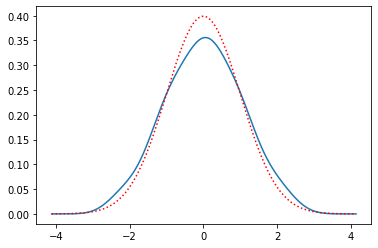

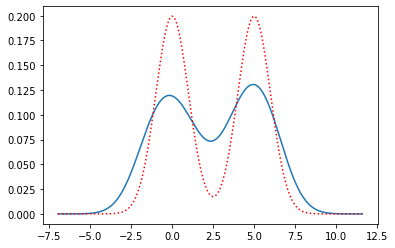

In [4]:
from scipy.stats import norm

n = 100
data = norm.rvs(size=n)
x,y = FFTKDE(kernel='gaussian', bw='silverman').\
   fit(data).evaluate()

plt.plot(x, y)

plt.plot(x, norm.pdf(x), color="red",
   linestyle="dotted")
plt.show()

data2 = [norm.rvs(size=round(n/2)), 
         norm.rvs(5,size=round(n/2))]
x,y = FFTKDE(kernel='gaussian', bw='silverman').\
   fit(data2).evaluate()

plt.plot(x, y)

plt.plot(x, 0.5*norm.pdf(x)+0.5*norm.pdf(x,5), 
   color="red", linestyle="dotted")
plt.show()

In [5]:
import yfinance as yf
Kdat = yf.download("K", start="2010-01-01",
   end="2018-12-31")
ldrK = np.log(Kdat['Adj Close']).diff()[1:]

[*********************100%***********************]  1 of 1 downloaded


\newpage 

Next, construct the kernel density estimate plot. Note that by setting `fit=norm`, we are able to see the best-fitting normal curve.

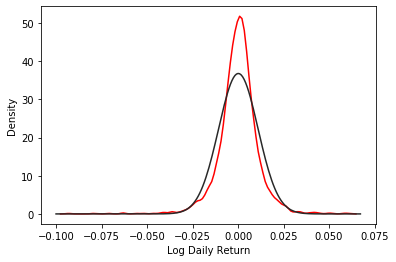

In [6]:
import seaborn as sns

ax = sns.distplot(ldrK, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", fit=norm)
plt.xlabel("Log Daily Return")
plt.ylabel("Density")
plt.show()

\newpage

The comparison on the log scale is much more informative.

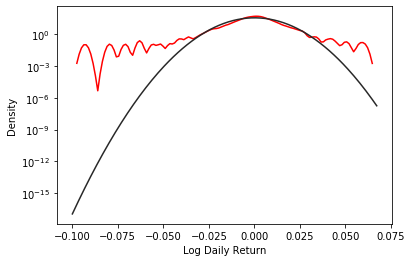

In [7]:
ax = sns.distplot(ldrK, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", fit=norm)
plt.xlabel("Log Daily Return")
plt.ylabel("Density")
plt.yscale("log")
plt.show()

**Exercise:** This example illustrates a common use for kernel density estimation, namely to assess the validity of an assumed parametric form. What conclusion can you draw in this case?

\answerlines{5}

\newpage

## Converting to the CDF and Percentiles {-}

The package `statsmodels` includes a function `KDEUnivariate()` which, while
is not as fast or flexible as the function provided by `KDEpy`, it does enable
easy calculation of the 
**cumulative distribution function (CDF)**
and its inverse (i.e., percentiles) derived from the smooth kernel density estimate.

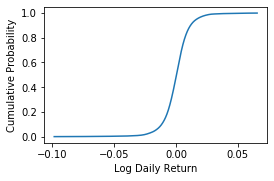

In [8]:
import statsmodels.api as sm
dens = sm.nonparametric.KDEUnivariate(ldrK)
dens.fit()

fig = plt.figure(figsize=(4,2.5),frameon=False)
plt.plot(dens.support,dens.cdf)
plt.xlabel("Log Daily Return")
plt.ylabel("Cumulative Probability")
plt.show()

It is possible to evaluate the CDF at any value using the following syntax.

In [9]:
from scipy.interpolate import interp1d

cdffunc = interp1d(dens.support, dens.cdf)

cdffunc(0)

array(0.47858166)

## Multivariate Density Estimation {-}

The idea of kernel density estimation extends naturally to $d$-dimensional data. Instead of a one-dimensional "bump" at each observation, the estimate is constructed from the sum of $d$-dimensional densities. The multivariate normal distribution is a standard choice.

**Exercise:** What are practical challenges to implementing this procedure?

\answerlines{10}

\newpage

The function `FFTKDE()` works easily with $d$-dimensional data, although automatic bandwidth selection is not implemented.

In [10]:
data = np.array(Kdat[['Adj Close','Volume']])
np.array(data)

kde = FFTKDE(kernel='gaussian')
kdefit = kde.fit(data)

The `evaluate()` function is useful. For example, the syntax `kdefit.evaluate(10)` will evaluate the estimate at a regularly-spaced 10 by 10 grid of points.

Kernel density estimation is a crucial tool for data exploration and visualization. `Seaborn` has a number of built-in functions that directly construct kernel density estimates. See the following example.

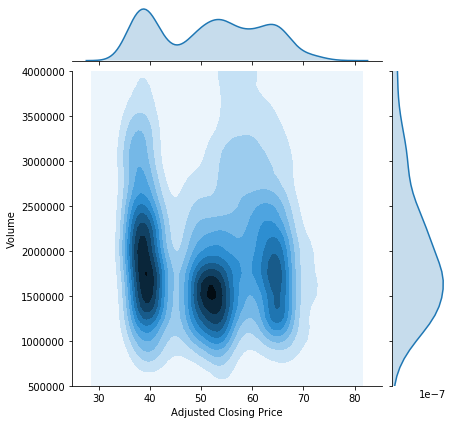

In [11]:
g = sns.jointplot(Kdat['Adj Close'], 
   Kdat['Volume'], kind="kde",bw="silverman")
g.set_axis_labels("Adjusted Closing Price",
   "Volume")
plt.ylim(500000,4000000)
plt.show()

See these other examples:
    
https://seaborn.pydata.org/examples/kde_ridgeplot.html

https://seaborn.pydata.org/examples/multiple_joint_kde.html

https://seaborn.pydata.org/examples/pair_grid_with_kde.html